## Imports

In [45]:
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_validate
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV, StratifiedKFold, RandomizedSearchCV, \
    HalvingRandomSearchCV
from sklearn.pipeline import Pipeline

## Load Data

In [47]:
target = 'Activity'
X_train = pd.read_csv('../data/train.csv')
y_train = X_train[target]
X_train = X_train.drop(columns=[target])

X_test = pd.read_csv('../data/test.csv')
y_test = X_test[target]
X_test = X_test.drop(columns=[target])

## Baseline Models

We fit both classifiers with **default hyperparameters** to establish a reference point before tuning.

### Random Forest

In [17]:
rf_baseline = RandomForestClassifier(random_state=1)
rf_baseline.fit(X_train, y_train)

y_pred = rf_baseline.predict(X_test)

rf_baseline_accuracy = accuracy_score(y_test, y_pred)
rf_baseline_f1 = f1_score(y_test, y_pred, average='macro') # WHY MACRO?
rf_classification_report = classification_report(y_test, y_pred)

print(rf_baseline_accuracy)
print(rf_baseline_f1)
print(rf_classification_report)

0.9256871394638616
0.9236888574188593
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.91      0.89      0.90       491
          STANDING       0.90      0.92      0.91       532
           WALKING       0.89      0.98      0.93       496
WALKING_DOWNSTAIRS       0.95      0.85      0.90       420
  WALKING_UPSTAIRS       0.91      0.90      0.91       471

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.93      0.93      2947



### Gradient Boosting

In [16]:
from sklearn.metrics import classification_report

gb_baseline = GradientBoostingClassifier(random_state=1)
gb_baseline.fit(X_train, y_train)

gb_baseline_accuracy = accuracy_score(y_test, gb_baseline.predict(X_test))
gb_baseline_f1 = f1_score(y_test, gb_baseline.predict(X_test), average='macro')
gb_classification_report = classification_report(y_test, gb_baseline.predict(X_test))

print(gb_baseline_accuracy)
print(gb_baseline_f1)
print(gb_classification_report)

0.9379029521547336
0.9372827399340696
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.93      0.85      0.89       491
          STANDING       0.87      0.94      0.91       532
           WALKING       0.94      0.98      0.96       496
WALKING_DOWNSTAIRS       0.97      0.92      0.95       420
  WALKING_UPSTAIRS       0.93      0.93      0.93       471

          accuracy                           0.94      2947
         macro avg       0.94      0.94      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



## Hyperparameter Tuning

### Random Forest
RF is fast to train, so we can afford a proper 3-fold CV with 25 random
configurations sampled from the parameter grid.

In [15]:
cv = StratifiedKFold(n_splits=3, shuffle=True,random_state=1)

rf_param_distribution = {
    'n_estimators': [100, 200],
    'max_depth': [5, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 3],
    'max_features': ['sqrt', 'log2'],
}

rf_search = RandomizedSearchCV(
    n_iter=25, estimator=RandomForestClassifier(random_state=1, n_jobs=1),
    n_jobs=-1, param_distributions=rf_param_distribution,
    cv=cv, scoring='f1_macro', verbose=2
)
rf_search.fit(X_train, y_train)
print(rf_search.best_params_)
print(rf_search.best_score_)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 15}
0.9779633693936168


### Gradient Boosting
Gradient boosting is significantly slower. Successive halving starts with the full
candidate set but allocates more resources only to promising configurations.

In [12]:
cv = StratifiedKFold(n_splits=2, shuffle=True,random_state=1)

gb_param_distribution = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'subsample': [0.75, 1.0],
    'learning_rate': [0.1, 0.3],
}

gb_search = HalvingRandomSearchCV(
    estimator=GradientBoostingClassifier(random_state=1),
    param_distributions=gb_param_distribution,
    cv=cv, scoring='f1_macro', verbose=2, factor=4, aggressive_elimination=True
)
gb_search.fit(X_train, y_train)
print(gb_search.best_params_)
print(gb_search.best_score_)

n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 5
min_resources_: 24
max_resources_: 7352
aggressive_elimination: True
factor: 4
----------
iter: 0
n_candidates: 16
n_resources: 384
Fitting 2 folds for each of 16 candidates, totalling 32 fits


C:\Users\m_sha\Documents\CS\Uni\Supervised Learning\Project\.venv\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 16 is smaller than n_iter=306. Running 16 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[CV] END learning_rate=0.1, max_depth=3, n_estimators=100, subsample=0.75; total time=  10.4s
[CV] END learning_rate=0.1, max_depth=3, n_estimators=100, subsample=0.75; total time=   8.9s
[CV] END learning_rate=0.1, max_depth=3, n_estimators=100, subsample=1.0; total time=  11.9s
[CV] END learning_rate=0.1, max_depth=3, n_estimators=100, subsample=1.0; total time=  22.5s
[CV] END learning_rate=0.1, max_depth=3, n_estimators=200, subsample=0.75; total time=  43.1s
[CV] END learning_rate=0.1, max_depth=3, n_estimators=200, subsample=0.75; total time=  44.8s
[CV] END learning_rate=0.1, max_depth=3, n_estimators=200, subsample=1.0; total time=  51.1s
[CV] END learning_rate=0.1, max_depth=3, n_estimators=200, subsample=1.0; total time=  51.0s
[CV] END learning_rate=0.1, max_depth=5, n_estimators=100, subsample=0.75; total time=  37.9s
[CV] END learning_rate=0.1, max_depth=5, n_estimators=100, subsample=0.75; total time=  27.4s
[CV] END learning_rate=0.1, max_depth=5, n_estimators=100, subsa

## Evaluate Tuned Models
Compare each model's baseline with the tuned one.

In [26]:
rf_best = rf_search.best_estimator_
gb_best = gb_search.best_estimator_

y_pred_rf = rf_best.predict(X_test)
y_pred_gb = gb_best.predict(X_test)

rf_metrics = pd.DataFrame({
    'Random Forest Baseline': {'Accuracy': rf_baseline_accuracy,
                               'Macro F1': rf_baseline_f1},
    'Random Forest Tuned': {'Accuracy': accuracy_score(y_test, y_pred_rf),
                            'Macro F1': f1_score(y_test, y_pred_rf,  average='macro')},
})

gb_metrics = pd.DataFrame({
    'Gradient Boosting Baseline':{'Accuracy': gb_baseline_accuracy,
                                  'Macro F1': gb_baseline_f1},
    'Gradient Boosting Tuned': {'Accuracy': accuracy_score(y_test, y_pred_gb),
                                'Macro F1': f1_score(y_test, y_pred_gb, average='macro')},
})

print(rf_metrics)
print(gb_metrics)

          Random Forest Baseline  Random Forest Tuned
Accuracy                0.925687             0.935528
Macro F1                0.923689             0.932925
          Gradient Boosting Baseline  Gradient Boosting Tuned
Accuracy                    0.937903                 0.928402
Macro F1                    0.937283                 0.927676


## Confusion Matrices

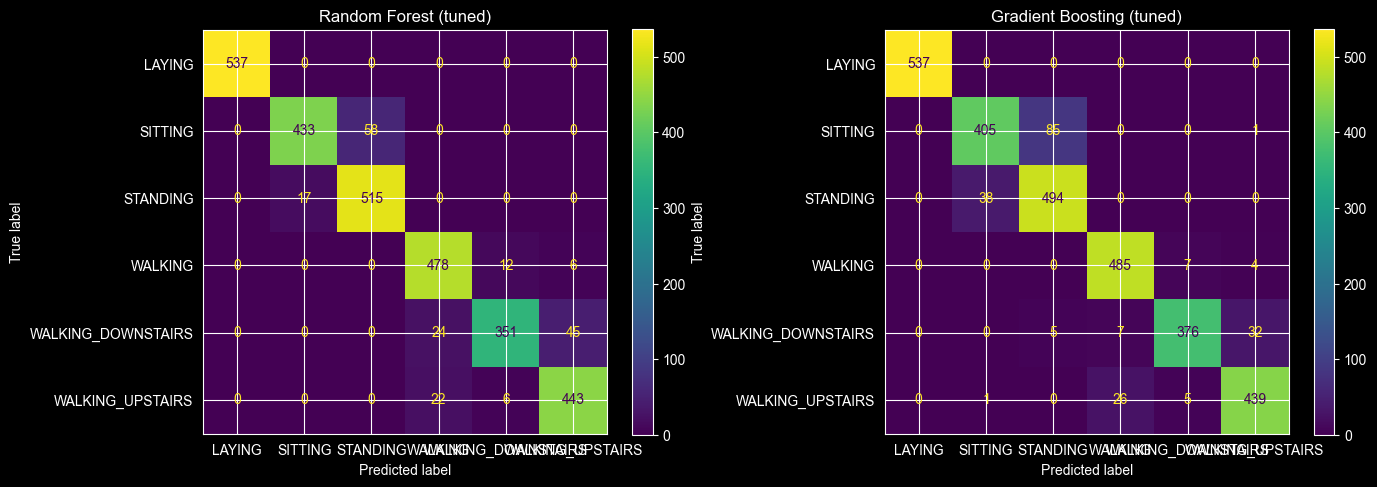

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_rf, y_pred_gb],
    ['Random Forest (tuned)', 'Gradient Boosting (tuned)']
):
    cm = confusion_matrix(y_test, y_pred, labels=sorted(y_test.unique()))
    display = ConfusionMatrixDisplay(cm, display_labels=sorted(y_test.unique()))
    display.plot(ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()

## Cross-Subject Evaluation

In [44]:
train_full = pd.read_csv('../data/train.csv')
test_full = pd.read_csv('../data/test.csv')

# Combine train & test so we can do a clean leave-subjects-out CV
X_all = pd.concat([train_full, test_full], ignore_index=True)
y_all = X_all[target]
groups = X_all['subject']
X_all = X_all.drop(columns=[target, 'subject'])

# Cross-subject CV: each fold holds out a different group of subjects entirely
cv_subject = StratifiedGroupKFold(n_splits=3)

for name, model in [('Random Forest', rf_best), ('Gradient Boosting', gb_best)]:
    scores = cross_validate(
        model, X_all, y_all,
        groups=groups,
        cv=cv_subject,
        scoring={'accuracy': 'accuracy', 'f1_macro': 'f1_macro'},
        n_jobs=-1,
    )
    print(f"\n{name} - Cross-Subject (StratifiedGroupKFold, 3 folds)")
    print(f"  Accuracy : {scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}")
    print(f"  Macro-F1 : {scores['test_f1_macro'].mean():.4f} ± {scores['test_f1_macro'].std():.4f}")


Random Forest - Cross-Subject (StratifiedGroupKFold, 3 folds)
  Accuracy : 0.9322 ± 0.0021
  Macro-F1 : 0.9291 ± 0.0028

Gradient Boosting - Cross-Subject (StratifiedGroupKFold, 3 folds)
  Accuracy : 0.9282 ± 0.0089
  Macro-F1 : 0.9270 ± 0.0100
